# Prepare data


Our goal is to get a small sample of the dataset to work with that is good enough to iterate on. A small sample makes it faster to iterate, hence enable easier debugging. If we can not make our model work on a reasonably small dataset then it's not likely to work on bigger one either.

We define a sufficiently small training dataset as:

- **Richness**: Every user should have at least 5 interactions and each item should have at least 10 interactions
- **Enough samples**: There should be at least 1000 users in the training dataset and about 1000 interactions in the validation set


# Set up


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

import plotly.express as px
from datasets import load_dataset
from loguru import logger

sys.path.insert(0, "..")

from src.cfg import ConfigLoader
from src.sample import InteractionDataSampler, calc_sparsity
from src.viz import custom_style_plotly

custom_style_plotly()

# Controller

In [3]:
cfg = ConfigLoader("../cfg/common.yaml")
cfg

{
  "run": {
    "author": "",
    "testing": false,
    "log_to_mlflow": true,
    "experiment_name": null,
    "run_name": null,
    "run_persist_dir": null,
    "random_seed": 41
  },
  "data": {
    "hf_datasets": {
      "name": "McAuley-Lab/Amazon-Reviews-2023",
      "mcauley_variant": "Books"
    },
    "train_fp": "/home/dvq/frostmourne/recsys-blog/1-seq-model/data/train.parquet",
    "val_fp": "/home/dvq/frostmourne/recsys-blog/1-seq-model/data/val.parquet",
    "idm_fp": "/home/dvq/frostmourne/recsys-blog/1-seq-model/data/idm.json",
    "metadata_fp": "/home/dvq/frostmourne/recsys-blog/1-seq-model/data/metadata.parquet",
    "train_features_fp": "/home/dvq/frostmourne/recsys-blog/1-seq-model/data/train_features.parquet",
    "val_features_fp": "/home/dvq/frostmourne/recsys-blog/1-seq-model/data/val_features.parquet",
    "full_features_neg_fp": "/home/dvq/frostmourne/recsys-blog/1-seq-model/data/full_features_neg_sampling_df.parquet",
    "train_features_neg_fp": "/home/dvq/

# Load data


In [4]:
logger.info(f"Dataset: {cfg.data.hf_datasets.name}")
logger.info(f"Category: {cfg.data.hf_datasets.mcauley_variant}")

dataset = load_dataset(
    cfg.data.hf_datasets.name,
    f"5core_timestamp_{cfg.data.hf_datasets.mcauley_variant}",
    trust_remote_code=True,
)

2025-06-07 10:43:05.501 | INFO     | __main__:<module>:1 - Dataset: McAuley-Lab/Amazon-Reviews-2023
2025-06-07 10:43:05.502 | INFO     | __main__:<module>:2 - Category: Books


In [5]:
dataset["train"]

Dataset({
    features: ['user_id', 'parent_asin', 'rating', 'timestamp'],
    num_rows: 8733855
})

In [6]:
dataset["valid"]

Dataset({
    features: ['user_id', 'parent_asin', 'rating', 'timestamp'],
    num_rows: 426209
})

In [7]:
def parse_dtype(df):
    return df.assign(
        rating=lambda df: df[cfg.data.rating_col].astype(float),
        timestamp=lambda df: df[cfg.data.timestamp_col].astype(int),
    )


train_raw = dataset["train"].to_pandas().pipe(parse_dtype)
val_raw = dataset["valid"].to_pandas().pipe(parse_dtype)

In [8]:
train_raw

,user_id,parent_asin,rating,timestamp
0,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1446304000,5.0,1441260345000
1,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1564770672,5.0,1441260365000
2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1442450703,5.0,1523093714024
3,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1780671067,1.0,1611623223325
4,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1645671127,3.0,1612044209266
...,...,...,...,...
8733850,AGZ44L7OCCLE76RJOZ3VGKOEKLFQ,0743259823,4.0,1102914217000
8733851,AGZ44L7OCCLE76RJOZ3VGKOEKLFQ,0891230513,3.0,1102921345000
8733852,AGZ44L7OCCLE76RJOZ3VGKOEKLFQ,0891230483,3.0,1102921945000
8733853,AGZ44L7OCCLE76RJOZ3VGKOEKLFQ,0500016909,2.0,1103970985000


In [10]:
logger.info(f"{calc_sparsity(train_raw, cfg.data.user_col, cfg.data.item_col)=:,.4%}")

2025-06-07 10:44:57.401 | INFO     | __main__:<module>:1 - calc_sparsity(train_raw, cfg.data.user_col, cfg.data.item_col)=99.9976%


# Sample


Just randomly get X users will not guarantee that the output dataset would qualify the condition of **richness**. Instead we take an iterative approach where we gradually drop random users from the dataset while keeping an eye on the conditions and our sampling target.


In [11]:
data_sampler = InteractionDataSampler(
    user_col=cfg.data.user_col,
    item_col=cfg.data.item_col,
    sample_users=cfg.sample.sample_users,
    min_val_records=cfg.sample.min_val_records,
    random_seed=cfg.run.random_seed,
    min_item_interactions=cfg.sample.min_item_interactions,
    min_user_interactions=cfg.sample.min_user_interactions,
    perc_users_removed_each_round=0.1,
    debug=False,
)

In [12]:
sample_df, val_sample_df = data_sampler.sample(train_raw, val_raw)

2025-06-07 10:45:30.582 | INFO     | src.sample:sample:118 - After randomly removing users - round 1: num_users=766,141
2025-06-07 10:45:30.582 | INFO     | src.sample:sample:122 - Number of users 766,141 are still greater than expected, keep removing...




Randomly removing 51848 users - Round 2 started


2025-06-07 10:45:51.949 | INFO     | src.sample:sample:118 - After randomly removing users - round 2: num_users=518,488
2025-06-07 10:45:51.950 | INFO     | src.sample:sample:122 - Number of users 518,488 are still greater than expected, keep removing...




Randomly removing 44504 users - Round 3 started


2025-06-07 10:46:17.589 | INFO     | src.sample:sample:118 - After randomly removing users - round 3: num_users=445,044
2025-06-07 10:46:17.590 | INFO     | src.sample:sample:122 - Number of users 445,044 are still greater than expected, keep removing...


...

2025-06-07 10:47:53.885 | INFO     | src.sample:sample:118 - After randomly removing users - round 17: num_users=36,672
2025-06-07 10:47:53.885 | INFO     | src.sample:sample:122 - Number of users 36,672 are still greater than expected, keep removing...




Randomly removing 2960 users - Round 18 started


2025-06-07 10:47:54.563 | INFO     | src.sample:sample:118 - After randomly removing users - round 18: num_users=29,605
2025-06-07 10:47:54.563 | INFO     | src.sample:sample:122 - Number of users 29,605 are still greater than expected, keep removing...




Randomly removing 2413 users - Round 19 started


2025-06-07 10:47:55.191 | INFO     | src.sample:sample:118 - After randomly removing users - round 19: num_users=24,137
2025-06-07 10:47:55.191 | INFO     | src.sample:sample:122 - Number of users 24,137 are still greater than expected, keep removing...
2025-06-07 10:47:55.219 | INFO     | src.sample:sample:137 - Number of val_df records 4,282 are falling below expected threshold, stop and use `sample_df` as final output...
2025-06-07 10:47:55.231 | INFO     | src.sample:sample:146 - len(sample_users)=19,734 len(sample_items)=7,388


In [13]:
train_sample_df = sample_df.copy()
sample_users = train_sample_df[cfg.data.user_col].unique()
sample_items = train_sample_df[cfg.data.item_col].unique()
logger.info(f"{len(sample_users)=} {len(sample_items)=}")

val_sample_df = val_raw.loc[
    lambda df: df[cfg.data.user_col].isin(sample_users)
    & df[cfg.data.item_col].isin(sample_items)
]

train_items = train_sample_df[cfg.data.item_col].unique()
train_users = train_sample_df[cfg.data.user_col].unique()
val_items = val_sample_df[cfg.data.item_col].unique()
val_users = val_sample_df[cfg.data.user_col].unique()

2025-06-07 10:47:55.260 | INFO     | __main__:<module>:4 - len(sample_users)=19734 len(sample_items)=7388


In [15]:
logger.info(f"{len(train_items)=}, {len(train_users)=}")
logger.info(f"{len(val_items)=}, {len(val_users)=}")
val_users_in_train = set(val_users).intersection(set(train_users))
val_items_in_train = set(val_items).intersection(set(train_items))
logger.info(
    f"Percentage of val users in train: {len(val_users_in_train) / len(val_users):,.0%}"
)
logger.info(
    f"Percentage of val items in train: {len(val_items_in_train) / len(val_items):,.0%}"
)
logger.info(f"{calc_sparsity(train_sample_df, cfg.data.user_col, cfg.data.item_col)=:,.4%}")

2025-06-07 10:48:16.565 | INFO     | __main__:<module>:1 - len(train_items)=7388, len(train_users)=19734
2025-06-07 10:48:16.566 | INFO     | __main__:<module>:2 - len(val_items)=1657, len(val_users)=1736
2025-06-07 10:48:16.568 | INFO     | __main__:<module>:5 - Percentage of val users in train: 100%
2025-06-07 10:48:16.569 | INFO     | __main__:<module>:8 - Percentage of val items in train: 100%
2025-06-07 10:48:16.583 | INFO     | __main__:<module>:11 - calc_sparsity(train_sample_df, cfg.data.user_col, cfg.data.item_col)=99.8666%


In [16]:
assert (
    train_sample_df.groupby(cfg.data.user_col).size().min()
    >= cfg.sample.min_user_interactions
)
assert (
    train_sample_df.groupby(cfg.data.item_col).size().min()
    >= cfg.sample.min_item_interactions
)

# Sample data


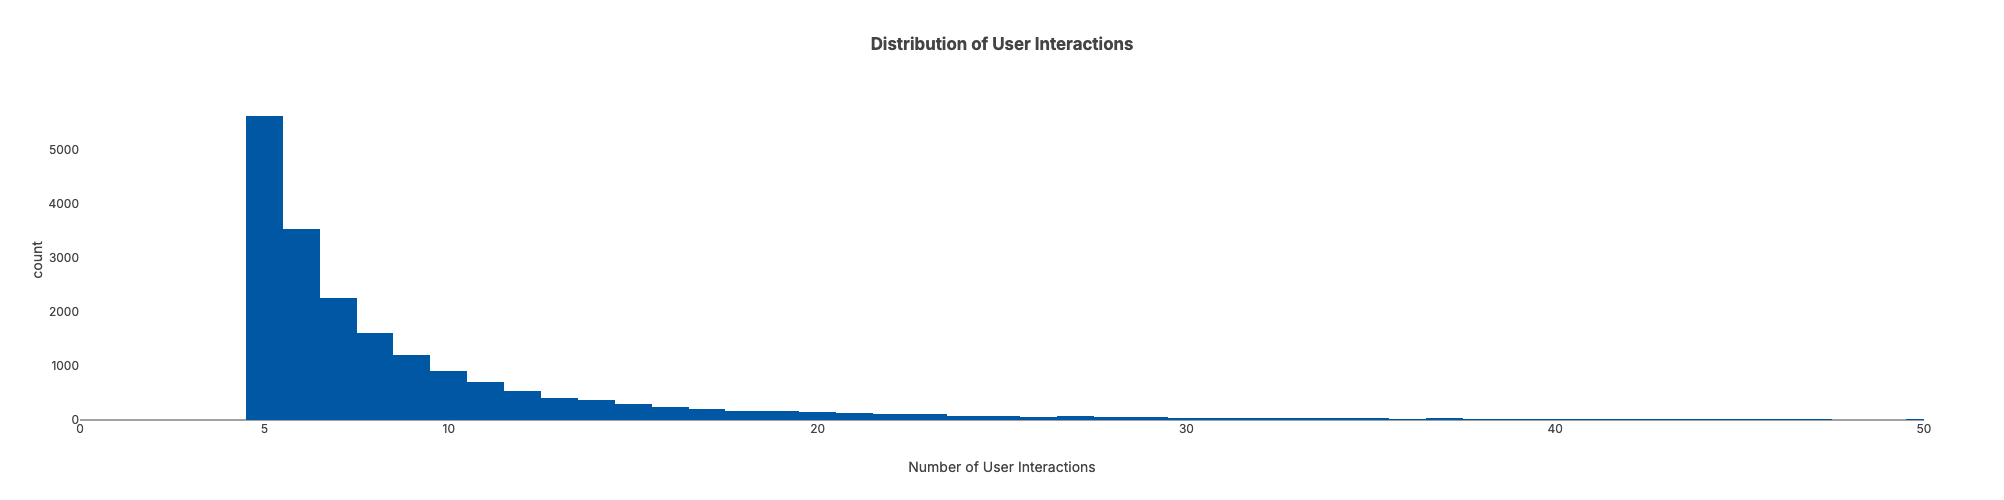

In [34]:
def _generate_x_labels(x: int):
    return [0, x, x*2, x*4, x*6, x*8, x*10]

tick_array = _generate_x_labels(cfg.sample.min_user_interactions)

fig = px.histogram(
    train_sample_df.groupby(cfg.data.user_col).size(),
    title="Distribution of User Interactions",
    width=800,
    height=500
)

fig.update_xaxes(
    tickmode='array',
    tickvals=tick_array,
    title="Number of User Interactions",
    range=[tick_array[0], tick_array[-1]]
)

fig.show()

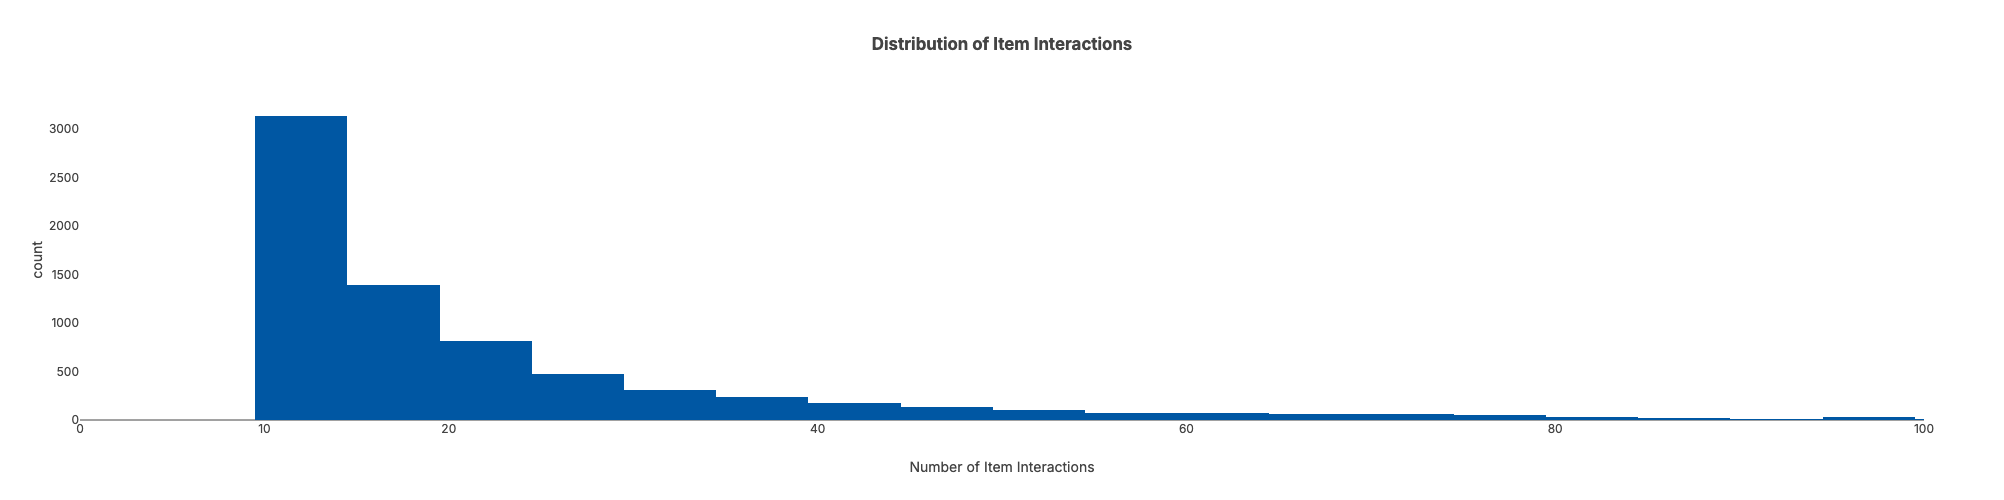

In [36]:
def _generate_x_labels(x: int):
    return [0, x, x*2, x*4, x*6, x*8, x*10]

tick_array = _generate_x_labels(cfg.sample.min_item_interactions)

fig = px.histogram(
    train_sample_df.groupby(cfg.data.item_col).size(),
    title="Distribution of Item Interactions",
    width=800,
    height=500
)

fig.update_xaxes(
    tickmode='array',
    tickvals=tick_array,
    title="Number of Item Interactions",
    range=[tick_array[0], tick_array[-1]]
)

fig.show()

In [27]:
train_sample_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,194424,19734,AHPUCLW72C2F6OVEAUN7OD5EYCWQ,196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
parent_asin,194424,7388,B00L9B7IKE,1248,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,194424.0,NaN,NaN,NaN,4.324538,0.990042,1.0,4.0,5.0,5.0,5.0
timestamp,194424.0,NaN,NaN,NaN,1458782492438.25,106331347545.285507,882469780000.0,1408495366750.0,1466428566000.0,1533243492307.25,1628641686214.0


# Persist sample


In [15]:
train_sample_df.to_parquet(cfg.data.train_fp)
val_sample_df.to_parquet(cfg.data.val_fp)